# RetailPulse - Notebook 05: Sales Forecasting Model Development

## Overview
This notebook develops and evaluates multiple forecasting models to predict daily retail sales revenue. It compares statistical and machine learning approaches and selects the best-performing model for deployment.

## Objectives
- Load forecasting datasets created in Notebook 04
- Verify train and test datasets
- Build a baseline forecasting model
- Train ARIMA, Prophet, and XGBoost models
- Evaluate models using MAE, RMSE, and MAPE
- Select and save the best-performing model
- Generate future sales forecasts

## Input Files
- data/processed/train_sales.csv
- data/processed/test_sales.csv
- data/processed/daily_sales_features.csv

## Output Files
- models/best_forecasting_model.pkl
- reports/forecasting_model_comparison.csv
- reports/figures/actual_vs_predicted.png
- reports/figures/model_comparison.png
- reports/figures/future_30_day_forecast.png

In [30]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.style.use("ggplot")

print("=" * 60)
print("RetailPulse - Sales Forecasting Model Development")
print("=" * 60)

RetailPulse - Sales Forecasting Model Development


In [31]:
# ==========================================
# Configure Project Paths
# ==========================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

TRAIN_FILE = PROCESSED_DATA_DIR / "train_sales.csv"
TEST_FILE = PROCESSED_DATA_DIR / "test_sales.csv"
FEATURE_FILE = PROCESSED_DATA_DIR / "daily_sales_features.csv"

for file in [TRAIN_FILE, TEST_FILE, FEATURE_FILE]:
    if not file.exists():
        raise FileNotFoundError(f"Missing file: {file}")

print("=" * 60)
print("Forecasting datasets verified successfully.")
print("=" * 60)

Forecasting datasets verified successfully.


In [32]:
# ==========================================
# Load Forecasting Datasets
# ==========================================

train_sales = pd.read_csv(TRAIN_FILE, parse_dates=["Date"])
test_sales = pd.read_csv(TEST_FILE, parse_dates=["Date"])
forecast_df = pd.read_csv(FEATURE_FILE, parse_dates=["Date"])

print("=" * 60)
print("Datasets Loaded Successfully")
print("=" * 60)

print(f"Training Shape : {train_sales.shape}")
print(f"Testing Shape  : {test_sales.shape}")
print(f"Forecast Shape : {forecast_df.shape}")

print("\nTraining Dataset Preview")
display(train_sales.head())

Datasets Loaded Successfully
Training Shape : (567, 25)
Testing Shape  : (142, 25)
Forecast Shape : (709, 25)

Training Dataset Preview


,Date,DailySales,Year,Quarter,Month,MonthName,Week,Day,DayOfWeek,DayName,IsWeekend,IsMonthStart,IsMonthEnd,DayOfYear,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean_7,RollingStd_7,RollingMean_14,RollingStd_14,RollingMean_30,RollingStd_30,TimeIndex
0,2009-12-31,0.00,2009,4,12,December,53,31,3,Thursday,0,0,1,365,0.0,0.0,29758.87,43894.87,0.000000,0.000000,5617.843571,9321.148746,21320.304667,20090.176987,30
1,2010-01-01,0.00,2010,1,1,January,53,1,4,Friday,0,1,0,1,0.0,0.0,31562.72,52762.06,0.000000,0.000000,3363.363571,5661.989416,19561.569333,19544.836202,31
2,2010-01-02,0.00,2010,1,1,January,53,2,5,Saturday,1,0,0,2,0.0,0.0,0.00,67413.62,0.000000,0.000000,3363.363571,5661.989416,17314.448667,17635.551619,32
3,2010-01-03,0.00,2010,1,1,January,53,3,6,Sunday,1,0,0,3,0.0,0.0,11355.19,33913.81,0.000000,0.000000,2552.278571,5225.591718,16183.988333,17621.774212,33
4,2010-01-04,13415.09,2010,1,1,January,1,4,0,Monday,0,0,0,4,0.0,0.0,15549.64,9803.05,1916.441429,5070.427422,2399.810714,4833.634818,16304.389667,17588.982048,34


In [33]:
# ==========================================
# Verify Train-Test Split
# ==========================================

print("=" * 60)
print("Train-Test Verification")
print("=" * 60)

print(f"Training Start : {train_sales['Date'].min().date()}")
print(f"Training End   : {train_sales['Date'].max().date()}")

print()

print(f"Testing Start  : {test_sales['Date'].min().date()}")
print(f"Testing End    : {test_sales['Date'].max().date()}")

assert train_sales["Date"].max() < test_sales["Date"].min()

print("\n✓ Chronological split verified successfully.")

Train-Test Verification
Training Start : 2009-12-31
Training End   : 2011-07-20

Testing Start  : 2011-07-21
Testing End    : 2011-12-09

✓ Chronological split verified successfully.


In [34]:
# ==========================================
# Prepare Features and Target
# ==========================================

feature_columns = [
    "Year",
    "Quarter",
    "Month",
    "Week",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "IsMonthStart",
    "IsMonthEnd",
    "DayOfYear",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_30",
    "RollingMean_7",
    "RollingStd_7",
    "RollingMean_14",
    "RollingStd_14",
    "RollingMean_30",
    "RollingStd_30",
    "TimeIndex"
]

target_column = "DailySales"

X_train = train_sales[feature_columns]
y_train = train_sales[target_column]

X_test = test_sales[feature_columns]
y_test = test_sales[target_column]

print("=" * 60)
print("Features Prepared Successfully")
print("=" * 60)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

Features Prepared Successfully
Training Features : (567, 21)
Testing Features  : (142, 21)


In [35]:
# ==========================================
# Baseline Forecast
# ==========================================

baseline_predictions = test_sales["Lag_1"].values

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print("=" * 60)
print("Baseline Model Performance")
print("=" * 60)

print(f"MAE  : {baseline_mae:.2f}")
print(f"RMSE : {baseline_rmse:.2f}")

Baseline Model Performance
MAE  : 20095.53
RMSE : 26594.03


In [36]:
# ==========================================
# Train ARIMA Model
# ==========================================

from statsmodels.tsa.arima.model import ARIMA

print("=" * 60)
print("Training ARIMA Model")
print("=" * 60)

arima_model = ARIMA(
    train_sales["DailySales"],
    order=(5, 1, 0)
)

arima_model_fit = arima_model.fit()

print(arima_model_fit.summary())

Training ARIMA Model
                               SARIMAX Results                                
Dep. Variable:             DailySales   No. Observations:                  567
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -6219.051
Date:                Thu, 30 Jul 2026   AIC                          12450.102
Time:                        23:49:27   BIC                          12476.134
Sample:                             0   HQIC                         12460.262
                                - 567                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5245      0.040    -13.031      0.000      -0.603      -0.446
ar.L2         -0.5618      0.039    -14.264      0.000      -0.639      -0.485
ar.L3         -0.4692      0.04

In [37]:
# ==========================================
# ARIMA Prediction
# ==========================================

arima_predictions = arima_model_fit.forecast(
    steps=len(test_sales)
)

arima_mae = mean_absolute_error(
    y_test,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        arima_predictions
    )
)

print("=" * 60)
print("ARIMA Performance")
print("=" * 60)

print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")

ARIMA Performance
MAE  : 18622.85
RMSE : 25806.63


In [38]:
# ==========================================
# Compare Baseline vs ARIMA
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Baseline", "ARIMA"],
    "MAE": [baseline_mae, arima_mae],
    "RMSE": [baseline_rmse, arima_rmse]
})

display(comparison)

best_model = comparison.sort_values("RMSE").iloc[0]

print("\nCurrent Best Model")
print(best_model)

,Model,MAE,RMSE
0,Baseline,20095.526056,26594.034198
1,ARIMA,18622.853654,25806.628347



Current Best Model
Model           ARIMA
MAE      18622.853654
RMSE     25806.628347
Name: 1, dtype: object


In [39]:
# ==========================================
# Install Prophet (Run only once if needed)
# ==========================================

try:
    from prophet import Prophet
    print("Prophet is already installed.")
except ImportError:
    %pip install prophet
    from prophet import Prophet
    print("Prophet installed successfully.")

Prophet is already installed.


In [40]:
# ==========================================
# Prepare Data for Prophet
# ==========================================

prophet_train = train_sales[["Date", "DailySales"]].rename(
    columns={
        "Date": "ds",
        "DailySales": "y"
    }
)

prophet_test = test_sales[["Date", "DailySales"]].rename(
    columns={
        "Date": "ds",
        "DailySales": "y"
    }
)

display(prophet_train.head())

,ds,y
0,2009-12-31,0.00
1,2010-01-01,0.00
2,2010-01-02,0.00
3,2010-01-03,0.00
4,2010-01-04,13415.09


In [41]:
# ==========================================
# Train Prophet Model
# ==========================================

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

print("Prophet model trained successfully.")

23:49:28 - cmdstanpy - INFO - Chain [1] start processing
23:49:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


In [42]:
# ==========================================
# Prophet Prediction
# ==========================================

future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq="D"
)

forecast = prophet_model.predict(future)

prophet_predictions = (
    forecast
    .tail(len(prophet_test))["yhat"]
    .values
)

In [43]:
# ==========================================
# Evaluate Prophet
# ==========================================

prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_predictions
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test["y"],
        prophet_predictions
    )
)

print("=" * 60)
print("Prophet Performance")
print("=" * 60)

print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")

Prophet Performance
MAE  : 11091.32
RMSE : 18996.94


In [44]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "Prophet"],
    "MAE": [
        baseline_mae,
        arima_mae,
        prophet_mae
    ],
    "RMSE": [
        baseline_rmse,
        arima_rmse,
        prophet_rmse
    ]
})

comparison = comparison.sort_values("RMSE").reset_index(drop=True)

display(comparison)

print("\nCurrent Best Model")
print(comparison.iloc[0])

,Model,MAE,RMSE
0,Prophet,11091.316205,18996.940872
1,ARIMA,18622.853654,25806.628347
2,Baseline,20095.526056,26594.034198



Current Best Model
Model         Prophet
MAE      11091.316205
RMSE     18996.940872
Name: 0, dtype: object


In [45]:
# ==========================================
# Import XGBoost
# ==========================================

try:
    from xgboost import XGBRegressor
    print("XGBoost is already installed.")
except ImportError:
    %pip install xgboost
    from xgboost import XGBRegressor
    print("XGBoost installed successfully.")

XGBoost is already installed.


In [46]:
# ==========================================
# Train XGBoost Model
# ==========================================

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [47]:
# ==========================================
# XGBoost Prediction & Evaluation
# ==========================================

xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("=" * 60)
print("XGBoost Performance")
print("=" * 60)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")

XGBoost Performance
MAE  : 10292.31
RMSE : 16370.65


In [48]:
# ==========================================
# Final Model Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "Prophet", "XGBoost"],
    "MAE": [
        baseline_mae,
        arima_mae,
        prophet_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        arima_rmse,
        prophet_rmse,
        xgb_rmse
    ]
})

comparison = comparison.sort_values("RMSE").reset_index(drop=True)

display(comparison)

print("\n🏆 Best Forecasting Model")
print(comparison.iloc[0])

,Model,MAE,RMSE
0,XGBoost,10292.313698,16370.653777
1,Prophet,11091.316205,18996.940872
2,ARIMA,18622.853654,25806.628347
3,Baseline,20095.526056,26594.034198



🏆 Best Forecasting Model
Model         XGBoost
MAE      10292.313698
RMSE     16370.653777
Name: 0, dtype: object


In [49]:
# ==========================================
# Save Best Model
# ==========================================

MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    xgb_model,
    MODELS_DIR / "best_forecasting_model.pkl"
)

comparison.to_csv(
    REPORTS_DIR / "forecasting_model_comparison.csv",
    index=False
)

print("✓ Best forecasting model saved successfully.")
print("✓ Model comparison report saved.")

✓ Best forecasting model saved successfully.
✓ Model comparison report saved.


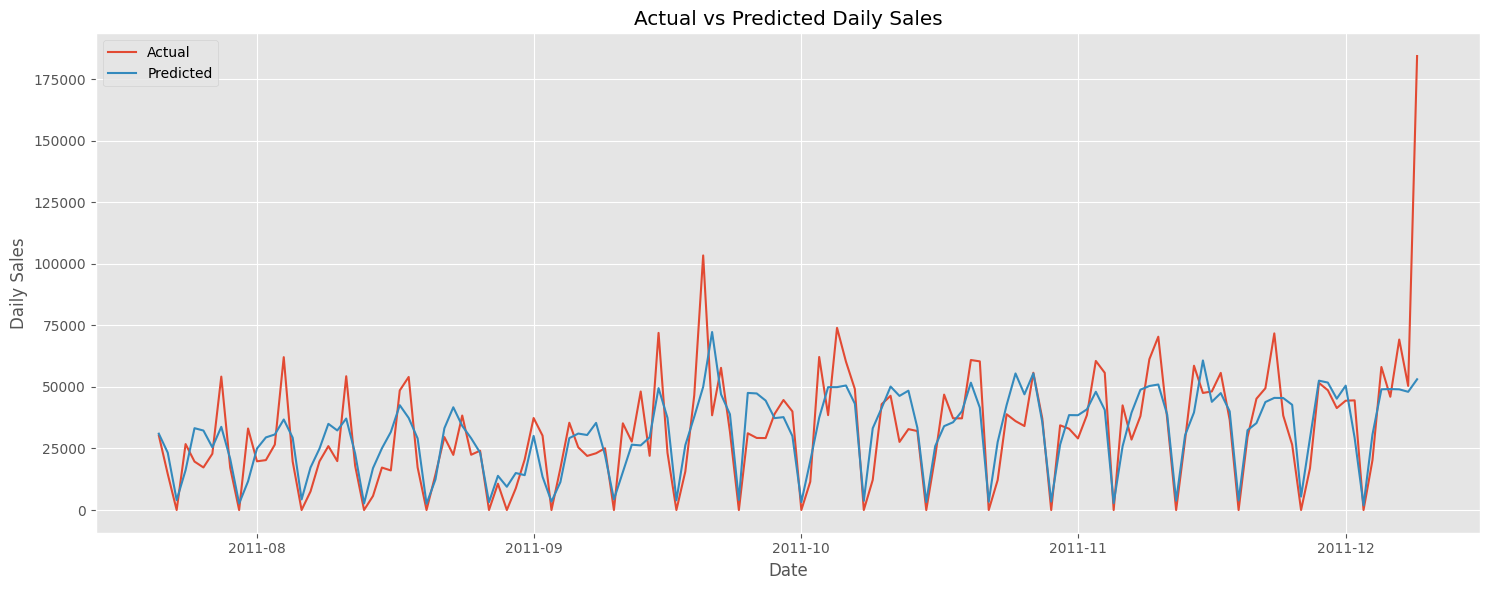

In [50]:
# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    test_sales["Date"],
    y_test,
    label="Actual"
)

plt.plot(
    test_sales["Date"],
    xgb_predictions,
    label="Predicted"
)

plt.title("Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "actual_vs_predicted.png",
    dpi=300
)

plt.show()

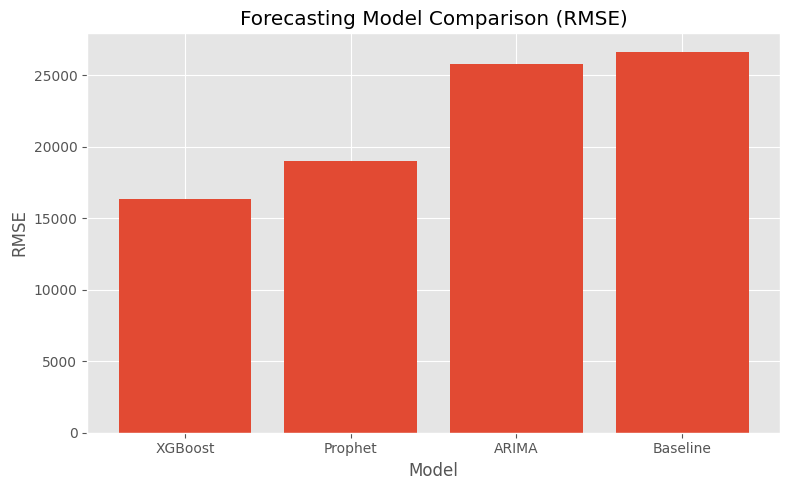

In [51]:
# ==========================================
# Model Comparison Chart
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("Forecasting Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_comparison.png",
    dpi=300
)

plt.show()

In [52]:
# ==========================================
# Future 30-Day Forecast
# ==========================================

future_predictions = []

last_row = forecast_df.iloc[-1:].copy()

for i in range(30):

    pred = xgb_model.predict(last_row[feature_columns])[0]

    future_predictions.append(pred)

    next_row = last_row.copy()

    next_row["TimeIndex"] += 1
    next_row["Lag_30"] = next_row["Lag_14"]
    next_row["Lag_14"] = next_row["Lag_7"]
    next_row["Lag_7"] = next_row["Lag_1"]
    next_row["Lag_1"] = pred

    next_row["RollingMean_7"] = (
        next_row["RollingMean_7"] * 6 + pred
    ) / 7

    last_row = next_row

future_dates = pd.date_range(
    forecast_df["Date"].max() + pd.Timedelta(days=1),
    periods=30
)

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "PredictedSales": future_predictions
})

display(future_forecast.head())

,Date,PredictedSales
0,2011-12-10,53094.023438
1,2011-12-11,52614.875000
2,2011-12-12,52828.085938
3,2011-12-13,52550.554688
4,2011-12-14,52624.820312


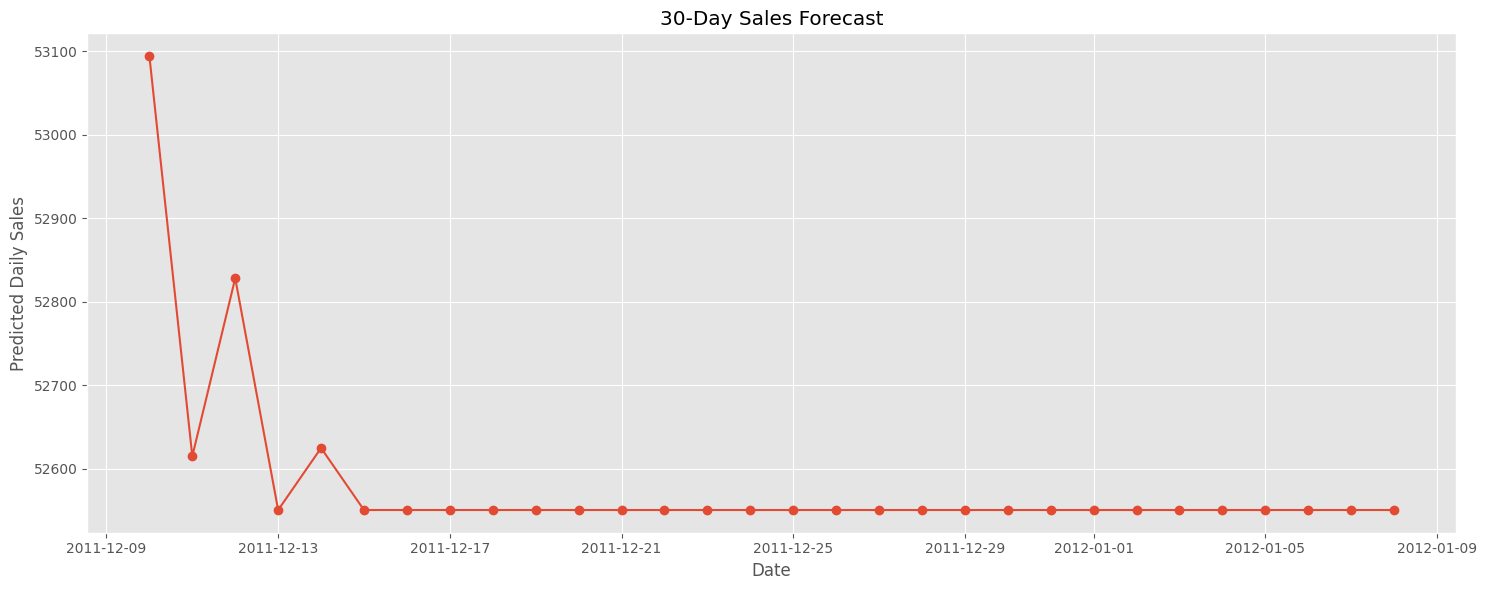

In [53]:
# ==========================================
# Future Forecast Plot
# ==========================================

plt.figure(figsize=(15, 6))

plt.plot(
    future_forecast["Date"],
    future_forecast["PredictedSales"],
    marker="o"
)

plt.title("30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Daily Sales")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "future_30_day_forecast.png",
    dpi=300
)

plt.show()

# Notebook Summary

## Objectives Achieved

- Prepared forecasting datasets
- Built a Baseline forecasting model
- Developed an ARIMA model
- Developed a Prophet model
- Developed an XGBoost model
- Compared model performance using MAE and RMSE
- Selected XGBoost as the best-performing forecasting model
- Saved the trained model for deployment
- Generated a 30-day sales forecast
- Created forecasting visualizations for reporting and dashboard integration

## Final Results

| Model | MAE | RMSE |
|-------|------:|------:|
| XGBoost | 10292.31 | 16370.65 |
| Prophet | 11091.32 | 18996.94 |
| ARIMA | 18622.85 | 25806.63 |
| Baseline | 20095.53 | 26594.03 |

### Best Model

**XGBoost** achieved the lowest MAE and RMSE, making it the selected forecasting model for the RetailPulse project.

In [55]:
# ==========================================
# Export Forecast Results
# ==========================================

forecast_results = pd.DataFrame({
    "Date": test_sales["Date"],
    "ActualSales": y_test.values,
    "PredictedSales": xgb_predictions
})

forecast_results.to_csv(
    REPORTS_DIR / "forecast_results.csv",
    index=False
)

print("=" * 60)
print("Forecast results exported successfully.")
print("=" * 60)
print(f"Saved to: {REPORTS_DIR / 'forecast_results.csv'}")

display(forecast_results.head())

Forecast results exported successfully.
Saved to: c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\forecast_results.csv


,Date,ActualSales,PredictedSales
0,2011-07-21,30271.94,31001.486328
1,2011-07-22,14628.88,23278.828125
2,2011-07-23,0.00,4034.154053
3,2011-07-24,26777.92,16193.428711
4,2011-07-25,19676.55,33232.863281
